In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error

print("DnCNN Baseline Experiment Started")
print("PyTorch version:", torch.__version__)

DnCNN Baseline Experiment Started
PyTorch version: 2.5.1+cu121


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU Memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

Using device: cuda
GPU: Quadro GV100
GPU Memory: 31.73 GB


In [3]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)

    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
GT_PATH = "../data/train/GT"

NOISY_PATH = "../data/train/NoisyLR"

print(
    "GT folder exists:",
    os.path.exists(GT_PATH)
)

print(
    "NoisyLR folder exists:",
    os.path.exists(NOISY_PATH)
)

GT folder exists: True
NoisyLR folder exists: True


In [5]:
files = sorted([
    f for f in os.listdir(GT_PATH)
    if f.endswith(".npy")
])

noisy_files = sorted([
    f for f in os.listdir(NOISY_PATH)
    if f.endswith(".npy")
])

print(
    "GT files:",
    len(files)
)

print(
    "NoisyLR files:",
    len(noisy_files)
)

print(
    "First GT file:",
    files[0]
)

print(
    "First NoisyLR file:",
    noisy_files[0]
)

GT files: 3200
NoisyLR files: 3200
First GT file: 000000.npy
First NoisyLR file: 000000.npy


In [6]:
sample_file = files[0]

gt = np.load(
    os.path.join(
        GT_PATH,
        sample_file
    )
)

noisy = np.load(
    os.path.join(
        NOISY_PATH,
        sample_file
    )
)

print(
    "Filename:",
    sample_file
)

print(
    "GT shape:",
    gt.shape
)

print(
    "NoisyLR shape:",
    noisy.shape
)

print(
    "GT dtype:",
    gt.dtype
)

print(
    "Noisy dtype:",
    noisy.dtype
)

print(
    "GT range:",
    gt.min(),
    gt.max()
)

print(
    "Noisy range:",
    noisy.min(),
    noisy.max()
)

Filename: 000000.npy
GT shape: (256, 256)
NoisyLR shape: (128, 128)
GT dtype: float32
Noisy dtype: float32
GT range: 0.0 1.0
Noisy range: -0.0026427102 1.3257757


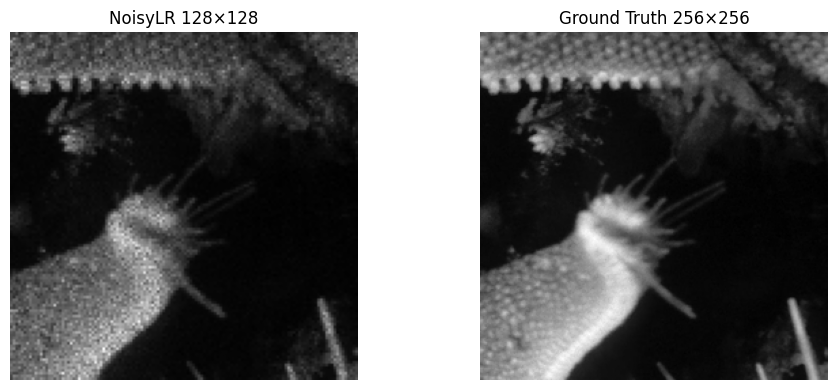

In [7]:
plt.figure(
    figsize=(10, 4)
)

plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    noisy,
    cmap="gray"
)

plt.title(
    "NoisyLR 128×128"
)

plt.axis("off")


plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    gt,
    cmap="gray"
)

plt.title(
    "Ground Truth 256×256"
)

plt.axis("off")


plt.tight_layout()

plt.show()

In [8]:
class SemiconductorDataset(Dataset):

    def __init__(
        self,
        gt_path,
        noisy_path,
        file_list
    ):

        self.gt_path = gt_path

        self.noisy_path = noisy_path

        self.files = file_list


    def __len__(self):

        return len(self.files)


    def __getitem__(
        self,
        idx
    ):

        filename = self.files[idx]

        gt = np.load(
            os.path.join(
                self.gt_path,
                filename
            )
        ).astype(
            np.float32
        )

        noisy = np.load(
            os.path.join(
                self.noisy_path,
                filename
            )
        ).astype(
            np.float32
        )


        # Upsample 128x128 -> 256x256

        noisy_up = resize(
            noisy,
            gt.shape,
            order=3,
            anti_aliasing=True,
            preserve_range=True
        ).astype(
            np.float32
        )


        gt_tensor = torch.from_numpy(
            gt
        ).unsqueeze(0)


        noisy_tensor = torch.from_numpy(
            noisy_up
        ).unsqueeze(0)


        return (
            noisy_tensor,
            gt_tensor
        )

In [9]:
np.random.seed(SEED)

indices = np.random.permutation(
    len(files)
)

train_end = int(
    0.80 * len(files)
)

val_end = int(
    0.90 * len(files)
)


train_files = [
    files[i]
    for i in indices[:train_end]
]


val_files = [
    files[i]
    for i in indices[
        train_end:val_end
    ]
]


test_files = [
    files[i]
    for i in indices[
        val_end:
    ]
]


print(
    "Total:",
    len(files)
)

print(
    "Training:",
    len(train_files)
)

print(
    "Validation:",
    len(val_files)
)

print(
    "Testing:",
    len(test_files)
)

Total: 3200
Training: 2560
Validation: 320
Testing: 320


In [10]:
train_dataset = SemiconductorDataset(
    GT_PATH,
    NOISY_PATH,
    train_files
)


val_dataset = SemiconductorDataset(
    GT_PATH,
    NOISY_PATH,
    val_files
)


test_dataset = SemiconductorDataset(
    GT_PATH,
    NOISY_PATH,
    test_files
)


print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

print(
    "Test dataset:",
    len(test_dataset)
)

Train dataset: 2560
Validation dataset: 320
Test dataset: 320


In [11]:
BATCH_SIZE = 8


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 320
Validation batches: 40
Test batches: 320


In [12]:
input_batch, gt_batch = next(
    iter(train_loader)
)


print(
    "Input batch:",
    input_batch.shape
)

print(
    "GT batch:",
    gt_batch.shape
)

print(
    "Input range:",
    input_batch.min().item(),
    input_batch.max().item()
)

print(
    "GT range:",
    gt_batch.min().item(),
    gt_batch.max().item()
)

Input batch: torch.Size([8, 1, 256, 256])
GT batch: torch.Size([8, 1, 256, 256])
Input range: -0.043583814054727554 1.6097135543823242
GT range: 0.0 1.0


In [13]:
noise_residual = (
    input_batch
    -
    gt_batch
)


print(
    "Residual shape:",
    noise_residual.shape
)


print(
    "Residual min:",
    noise_residual.min().item()
)


print(
    "Residual max:",
    noise_residual.max().item()
)


print(
    "Residual mean:",
    noise_residual.mean().item()
)

Residual shape: torch.Size([8, 1, 256, 256])
Residual min: -0.6573511362075806
Residual max: 0.7238490581512451
Residual mean: -8.864491246640682e-05


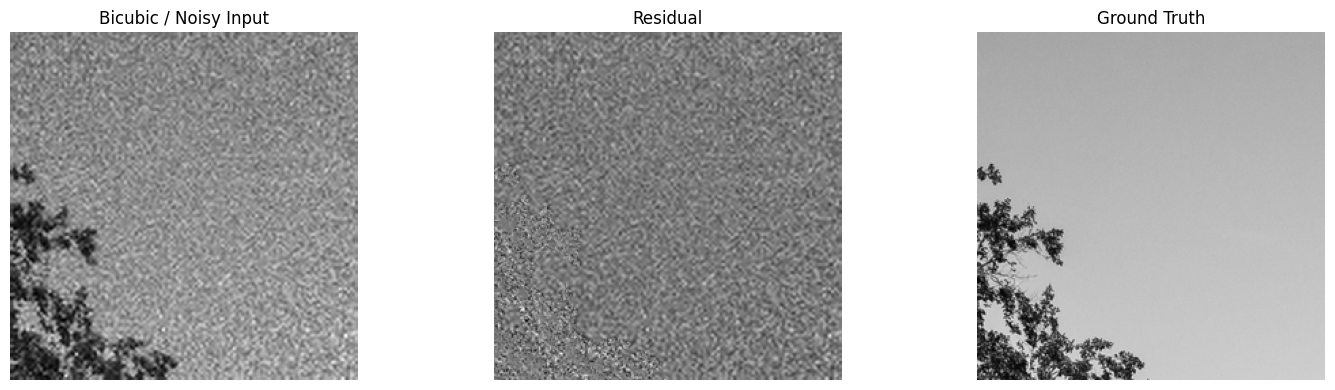

In [14]:
plt.figure(
    figsize=(15, 4)
)


plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    input_batch[0]
    .squeeze()
    .numpy(),
    cmap="gray"
)

plt.title(
    "Bicubic / Noisy Input"
)

plt.axis("off")


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    noise_residual[0]
    .squeeze()
    .numpy(),
    cmap="gray"
)

plt.title(
    "Residual"
)

plt.axis("off")


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    gt_batch[0]
    .squeeze()
    .numpy(),
    cmap="gray"
)

plt.title(
    "Ground Truth"
)

plt.axis("off")


plt.tight_layout()

plt.show()

In [15]:
class DnCNN(nn.Module):

    def __init__(
        self,
        channels=1,
        num_layers=17,
        features=64
    ):

        super(
            DnCNN,
            self
        ).__init__()


        layers = []


        # First layer

        layers.append(
            nn.Conv2d(
                channels,
                features,
                kernel_size=3,
                padding=1,
                bias=True
            )
        )


        layers.append(
            nn.ReLU(
                inplace=True
            )
        )


        # Middle layers

        for _ in range(
            num_layers - 2
        ):

            layers.append(
                nn.Conv2d(
                    features,
                    features,
                    kernel_size=3,
                    padding=1,
                    bias=False
                )
            )


            layers.append(
                nn.BatchNorm2d(
                    features
                )
            )


            layers.append(
                nn.ReLU(
                    inplace=True
                )
            )


        # Final layer predicts residual

        layers.append(
            nn.Conv2d(
                features,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            )
        )


        self.dncnn = nn.Sequential(
            *layers
        )


    def forward(
        self,
        x
    ):

        noise = self.dncnn(
            x
        )

        clean = x - noise

        return clean

In [16]:
model = DnCNN(
    channels=1,
    num_layers=17,
    features=64
).to(
    device
)


print(model)

DnCNN(
  (dncnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Conv2d(64, 64, kernel_size=(3, 3), str

In [17]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(
    "Total parameters:",
    total_params
)


print(
    "Trainable parameters:",
    trainable_params
)

Total parameters: 556096
Trainable parameters: 556096


In [18]:
criterion = nn.MSELoss()


optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)


print(
    "Loss: MSE"
)

print(
    "Optimizer: Adam"
)

print(
    "Learning Rate: 0.001"
)

Loss: MSE
Optimizer: Adam
Learning Rate: 0.001


In [19]:
MODEL_PATH = (
    "../models/dncnn"
)


RESULT_PATH = (
    "../results/dncnn"
)


RESTORED_PATH = (
    "../results/dncnn/restored"
)


IMAGE_PATH = (
    "../results/dncnn/images"
)


EXAMPLE_PATH = (
    "../results/dncnn/examples"
)


os.makedirs(
    MODEL_PATH,
    exist_ok=True
)


os.makedirs(
    RESULT_PATH,
    exist_ok=True
)


os.makedirs(
    RESTORED_PATH,
    exist_ok=True
)


os.makedirs(
    IMAGE_PATH,
    exist_ok=True
)


os.makedirs(
    EXAMPLE_PATH,
    exist_ok=True
)


print(
    "DnCNN folders created"
)

DnCNN folders created


In [20]:
EPOCHS = 20


train_loss_history = []

val_loss_history = []


best_val_loss = float(
    "inf"
)


for epoch in range(
    EPOCHS
):


    # =====================
    # TRAINING
    # =====================

    model.train()


    running_train_loss = 0.0


    for (
        input_img,
        gt_img
    ) in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):


        input_img = input_img.to(
            device
        )


        gt_img = gt_img.to(
            device
        )


        optimizer.zero_grad()


        output = model(
            input_img
        )


        loss = criterion(
            output,
            gt_img
        )


        loss.backward()


        optimizer.step()


        running_train_loss += (
            loss.item()
        )


    train_loss = (
        running_train_loss
        /
        len(train_loader)
    )


    train_loss_history.append(
        train_loss
    )


    # =====================
    # VALIDATION
    # =====================

    model.eval()


    running_val_loss = 0.0


    with torch.no_grad():


        for (
            input_img,
            gt_img
        ) in val_loader:


            input_img = input_img.to(
                device
            )


            gt_img = gt_img.to(
                device
            )


            output = model(
                input_img
            )


            val_loss = criterion(
                output,
                gt_img
            )


            running_val_loss += (
                val_loss.item()
            )


    val_loss = (
        running_val_loss
        /
        len(val_loader)
    )


    val_loss_history.append(
        val_loss
    )


    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    # =====================
    # SAVE BEST MODEL
    # =====================

    if val_loss < best_val_loss:


        best_val_loss = (
            val_loss
        )


        torch.save(
            model.state_dict(),
            "../models/dncnn/dncnn_best.pth"
        )


        print(
            "Best DnCNN model saved."
        )

Epoch 1/20: 100%|██████████| 320/320 [01:15<00:00,  4.24it/s]


Epoch [01/20] Train Loss: 0.007833 | Val Loss: 0.004384
Best DnCNN model saved.


Epoch 2/20: 100%|██████████| 320/320 [01:11<00:00,  4.46it/s]


Epoch [02/20] Train Loss: 0.003558 | Val Loss: 0.004263
Best DnCNN model saved.


Epoch 3/20: 100%|██████████| 320/320 [01:11<00:00,  4.48it/s]


...

Epoch [18/20] Train Loss: 0.003151 | Val Loss: 0.004056


Epoch 19/20: 100%|██████████| 320/320 [01:11<00:00,  4.50it/s]


Epoch [19/20] Train Loss: 0.003142 | Val Loss: 0.003797
Best DnCNN model saved.


Epoch 20/20: 100%|██████████| 320/320 [01:15<00:00,  4.22it/s]


Epoch [20/20] Train Loss: 0.003133 | Val Loss: 0.003966


In [21]:
torch.save(
    model.state_dict(),
    "../models/dncnn/dncnn_final.pth"
)


print(
    "Final DnCNN model saved"
)

Final DnCNN model saved


In [22]:
history_df = pd.DataFrame({

    "Epoch":
        range(
            1,
            EPOCHS + 1
        ),

    "Train_Loss":
        train_loss_history,

    "Validation_Loss":
        val_loss_history

})


history_df.to_csv(
    "../results/dncnn/training_history.csv",
    index=False
)


history_df

,Epoch,Train_Loss,Validation_Loss
0,1,0.007833,0.004384
1,2,0.003558,0.004263
2,3,0.003427,0.004201
3,4,0.003370,0.004081
4,5,0.003336,0.004271
5,6,0.003327,0.003978
6,7,0.003297,0.003944
7,8,0.003277,0.003966
8,9,0.003271,0.003915
9,10,0.003238,0.003898


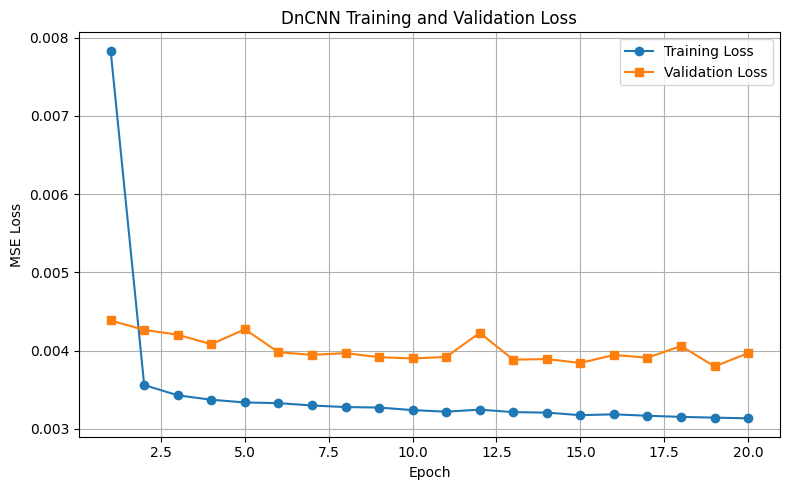

In [23]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    range(
        1,
        EPOCHS + 1
    ),
    train_loss_history,
    marker="o",
    label="Training Loss"
)


plt.plot(
    range(
        1,
        EPOCHS + 1
    ),
    val_loss_history,
    marker="s",
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "DnCNN Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()


plt.savefig(
    "../results/dncnn/training_curve.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [24]:
best_model = DnCNN(
    channels=1,
    num_layers=17,
    features=64
).to(
    device
)


best_model.load_state_dict(
    torch.load(
        "../models/dncnn/dncnn_best.pth",
        map_location=device
    )
)


best_model.eval()


print(
    "Best DnCNN model loaded"
)

Best DnCNN model loaded


/tmp/ipykernel_1987098/854596576.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [25]:
psnr_scores = []

ssim_scores = []

mse_scores = []

inference_times = []


best_model.eval()


with torch.no_grad():


    for i, (
        input_img,
        gt_img
    ) in enumerate(
        tqdm(
            test_loader,
            desc="Testing DnCNN"
        )
    ):


        input_img = input_img.to(
            device
        )


        if device.type == "cuda":

            torch.cuda.synchronize()


        start_time = (
            time.perf_counter()
        )


        output = best_model(
            input_img
        )


        if device.type == "cuda":

            torch.cuda.synchronize()


        end_time = (
            time.perf_counter()
        )


        inference_ms = (
            end_time
            -
            start_time
        ) * 1000


        output = torch.clamp(
            output,
            0,
            1
        )


        restored = (
            output
            .squeeze()
            .cpu()
            .numpy()
        )


        gt = (
            gt_img
            .squeeze()
            .numpy()
        )


        current_psnr = (
            peak_signal_noise_ratio(
                gt,
                restored,
                data_range=1.0
            )
        )


        current_ssim = (
            structural_similarity(
                gt,
                restored,
                data_range=1.0
            )
        )


        current_mse = (
            mean_squared_error(
                gt,
                restored
            )
        )


        psnr_scores.append(
            current_psnr
        )


        ssim_scores.append(
            current_ssim
        )


        mse_scores.append(
            current_mse
        )


        inference_times.append(
            inference_ms
        )


        filename = (
            test_files[i]
        )


        np.save(
            os.path.join(
                RESTORED_PATH,
                filename
            ),
            restored
        )


print(
    "DnCNN testing completed"
)

Testing DnCNN: 100%|██████████| 320/320 [00:06<00:00, 48.71it/s]

DnCNN testing completed


In [26]:
avg_psnr = np.mean(
    psnr_scores
)


avg_ssim = np.mean(
    ssim_scores
)


avg_mse = np.mean(
    mse_scores
)


avg_inference = np.mean(
    inference_times
)


print(
    "========== DnCNN FINAL RESULTS =========="
)


print(
    f"Average PSNR: {avg_psnr:.6f} dB"
)


print(
    f"Average SSIM: {avg_ssim:.6f}"
)


print(
    f"Average MSE: {avg_mse:.8f}"
)


print(
    f"Average Inference Time: {avg_inference:.3f} ms/image"
)

========== DnCNN FINAL RESULTS ==========
Average PSNR: 27.893001 dB
Average SSIM: 0.724960
Average MSE: 0.00257483
Average Inference Time: 6.864 ms/image


In [27]:
metrics_df = pd.DataFrame({

    "Filename":
        test_files,

    "PSNR_dB":
        psnr_scores,

    "SSIM":
        ssim_scores,

    "MSE":
        mse_scores,

    "Inference_Time_ms":
        inference_times

})


metrics_df.to_csv(
    "../results/dncnn/per_image_metrics.csv",
    index=False
)


metrics_df.head(
    10
)

,Filename,PSNR_dB,SSIM,MSE,Inference_Time_ms
0,001218.npy,27.392884,0.778248,0.001823,9.808377
1,001158.npy,27.911794,0.523949,0.001617,6.864030
2,001415.npy,21.327485,0.711170,0.007366,6.852154
3,002896.npy,28.910362,0.792912,0.001285,6.847999
4,001527.npy,35.298746,0.888204,0.000295,6.847337
5,003113.npy,25.066900,0.804448,0.003114,6.861556
6,001300.npy,33.433205,0.863072,0.000454,6.838994
7,003056.npy,23.764708,0.676395,0.004203,6.874980
8,002848.npy,30.083003,0.692806,0.000981,6.834572
9,001603.npy,26.154815,0.764321,0.002424,6.848421


In [28]:
metrics_file = (
    "../results/dncnn/metrics.txt"
)


with open(
    metrics_file,
    "w"
) as f:


    f.write(
        "Experiment: DnCNN Baseline\n"
    )


    f.write(
        "==========================\n\n"
    )


    f.write(
        "Dataset: KLA Semiconductor Image Restoration\n\n"
    )


    f.write(
        f"Training Samples: {len(train_files)}\n"
    )


    f.write(
        f"Validation Samples: {len(val_files)}\n"
    )


    f.write(
        f"Testing Samples: {len(test_files)}\n\n"
    )


    f.write(
        "Input: NoisyLR 128x128\n"
    )


    f.write(
        "Preprocessing: Bicubic Upsampling to 256x256\n"
    )


    f.write(
        "Model: DnCNN 17 Layers\n"
    )


    f.write(
        "Residual Learning: Yes\n\n"
    )


    f.write(
        f"Average PSNR: {avg_psnr:.6f} dB\n"
    )


    f.write(
        f"Average SSIM: {avg_ssim:.6f}\n"
    )


    f.write(
        f"Average MSE: {avg_mse:.10f}\n"
    )


    f.write(
        f"Average Inference Time: {avg_inference:.4f} ms/image\n"
    )


    f.write(
        f"Model Parameters: {total_params}\n"
    )


print(
    "DnCNN metrics saved"
)

DnCNN metrics saved


In [29]:
bicubic_psnr = []

bicubic_ssim = []

bicubic_mse = []


for filename in tqdm(
    test_files,
    desc="Evaluating Bicubic"
):


    gt = np.load(
        os.path.join(
            GT_PATH,
            filename
        )
    ).astype(
        np.float32
    )


    noisy = np.load(
        os.path.join(
            NOISY_PATH,
            filename
        )
    ).astype(
        np.float32
    )


    bicubic = resize(
        noisy,
        gt.shape,
        order=3,
        anti_aliasing=True,
        preserve_range=True
    )


    bicubic_psnr.append(
        peak_signal_noise_ratio(
            gt,
            bicubic,
            data_range=1.0
        )
    )


    bicubic_ssim.append(
        structural_similarity(
            gt,
            bicubic,
            data_range=1.0
        )
    )


    bicubic_mse.append(
        mean_squared_error(
            gt,
            bicubic
        )
    )


print(
    "Bicubic PSNR:",
    np.mean(
        bicubic_psnr
    )
)


print(
    "Bicubic SSIM:",
    np.mean(
        bicubic_ssim
    )
)


print(
    "Bicubic MSE:",
    np.mean(
        bicubic_mse
    )
)

Evaluating Bicubic: 100%|██████████| 320/320 [00:03<00:00, 101.55it/s]

Bicubic PSNR: 22.478415628140233
Bicubic SSIM: 0.5116624465067319
Bicubic MSE: 0.007338321273890881


In [30]:
srcnn_psnr = 27.52943205674495

srcnn_ssim = 0.7250710888767316

srcnn_mse = 0.0027344456903774946


print(
    "SRCNN PSNR:",
    srcnn_psnr
)

print(
    "SRCNN SSIM:",
    srcnn_ssim
)

print(
    "SRCNN MSE:",
    srcnn_mse
)

SRCNN PSNR: 27.52943205674495
SRCNN SSIM: 0.7250710888767316
SRCNN MSE: 0.0027344456903774946


In [31]:
comparison_df = pd.DataFrame({

    "Method": [
        "Bicubic",
        "SRCNN",
        "DnCNN"
    ],


    "PSNR_dB": [
        np.mean(
            bicubic_psnr
        ),

        srcnn_psnr,

        avg_psnr
    ],


    "SSIM": [
        np.mean(
            bicubic_ssim
        ),

        srcnn_ssim,

        avg_ssim
    ],


    "MSE": [
        np.mean(
            bicubic_mse
        ),

        srcnn_mse,

        avg_mse
    ]

})


comparison_df.to_csv(
    "../results/dncnn/baseline_comparison.csv",
    index=False
)


comparison_df

,Method,PSNR_dB,SSIM,MSE
0,Bicubic,22.478416,0.511662,0.007338
1,SRCNN,27.529432,0.725071,0.002734
2,DnCNN,27.893001,0.724960,0.002575


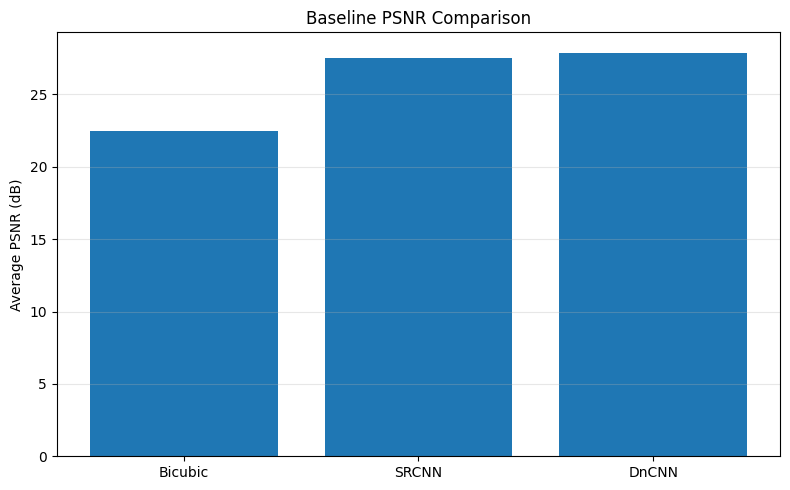

In [32]:
plt.figure(
    figsize=(8, 5)
)


plt.bar(
    comparison_df[
        "Method"
    ],

    comparison_df[
        "PSNR_dB"
    ]
)


plt.ylabel(
    "Average PSNR (dB)"
)


plt.title(
    "Baseline PSNR Comparison"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "../results/dncnn/psnr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

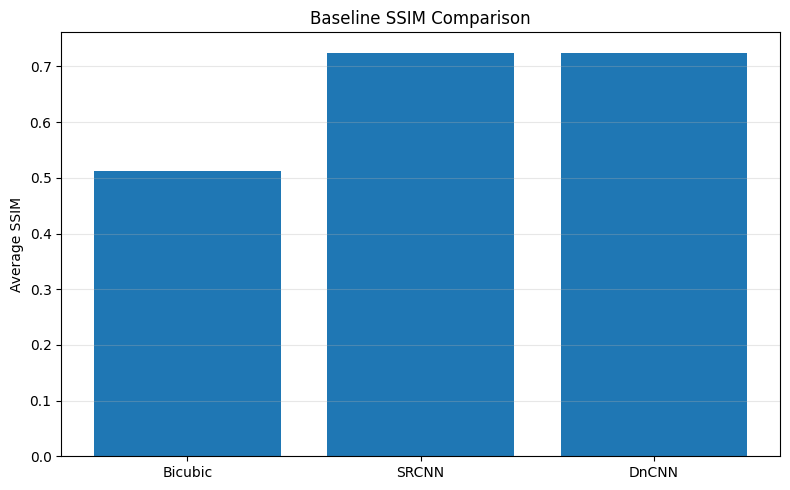

In [33]:
plt.figure(
    figsize=(8, 5)
)


plt.bar(
    comparison_df[
        "Method"
    ],

    comparison_df[
        "SSIM"
    ]
)


plt.ylabel(
    "Average SSIM"
)


plt.title(
    "Baseline SSIM Comparison"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "../results/dncnn/ssim_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

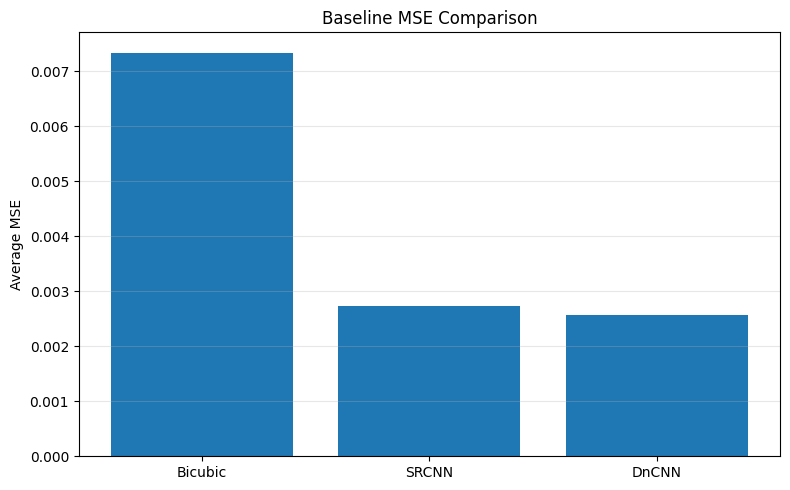

In [34]:
plt.figure(
    figsize=(8, 5)
)


plt.bar(
    comparison_df[
        "Method"
    ],

    comparison_df[
        "MSE"
    ]
)


plt.ylabel(
    "Average MSE"
)


plt.title(
    "Baseline MSE Comparison"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "../results/dncnn/mse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [35]:
restored_files = sorted([
    f for f in os.listdir(
        RESTORED_PATH
    )
    if f.endswith(
        ".npy"
    )
])


print(
    "Restored files:",
    len(restored_files)
)


for filename in tqdm(
    restored_files
):


    image = np.load(
        os.path.join(
            RESTORED_PATH,
            filename
        )
    )


    png_name = filename.replace(
        ".npy",
        ".png"
    )


    plt.imsave(
        os.path.join(
            IMAGE_PATH,
            png_name
        ),
        image,
        cmap="gray"
    )


print(
    "DnCNN PNG images saved"
)

Restored files: 320


100%|██████████| 320/320 [00:07<00:00, 45.50it/s]

DnCNN PNG images saved


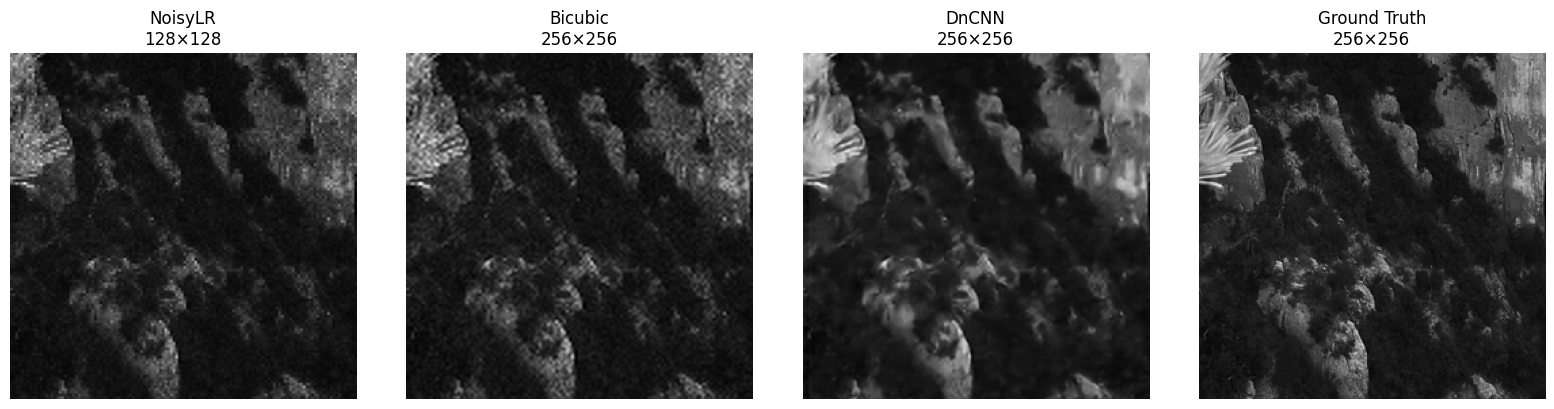

In [36]:
sample_file = test_files[0]


gt = np.load(
    os.path.join(
        GT_PATH,
        sample_file
    )
)


noisy = np.load(
    os.path.join(
        NOISY_PATH,
        sample_file
    )
)


bicubic = resize(
    noisy,
    gt.shape,
    order=3,
    anti_aliasing=True,
    preserve_range=True
)


dncnn = np.load(
    os.path.join(
        RESTORED_PATH,
        sample_file
    )
)


plt.figure(
    figsize=(16, 4)
)


plt.subplot(
    1,
    4,
    1
)

plt.imshow(
    noisy,
    cmap="gray"
)

plt.title(
    "NoisyLR\n128×128"
)

plt.axis("off")


plt.subplot(
    1,
    4,
    2
)

plt.imshow(
    bicubic,
    cmap="gray"
)

plt.title(
    "Bicubic\n256×256"
)

plt.axis("off")


plt.subplot(
    1,
    4,
    3
)

plt.imshow(
    dncnn,
    cmap="gray"
)

plt.title(
    "DnCNN\n256×256"
)

plt.axis("off")


plt.subplot(
    1,
    4,
    4
)

plt.imshow(
    gt,
    cmap="gray"
)

plt.title(
    "Ground Truth\n256×256"
)

plt.axis("off")


plt.tight_layout()


plt.savefig(
    "../results/dncnn/comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

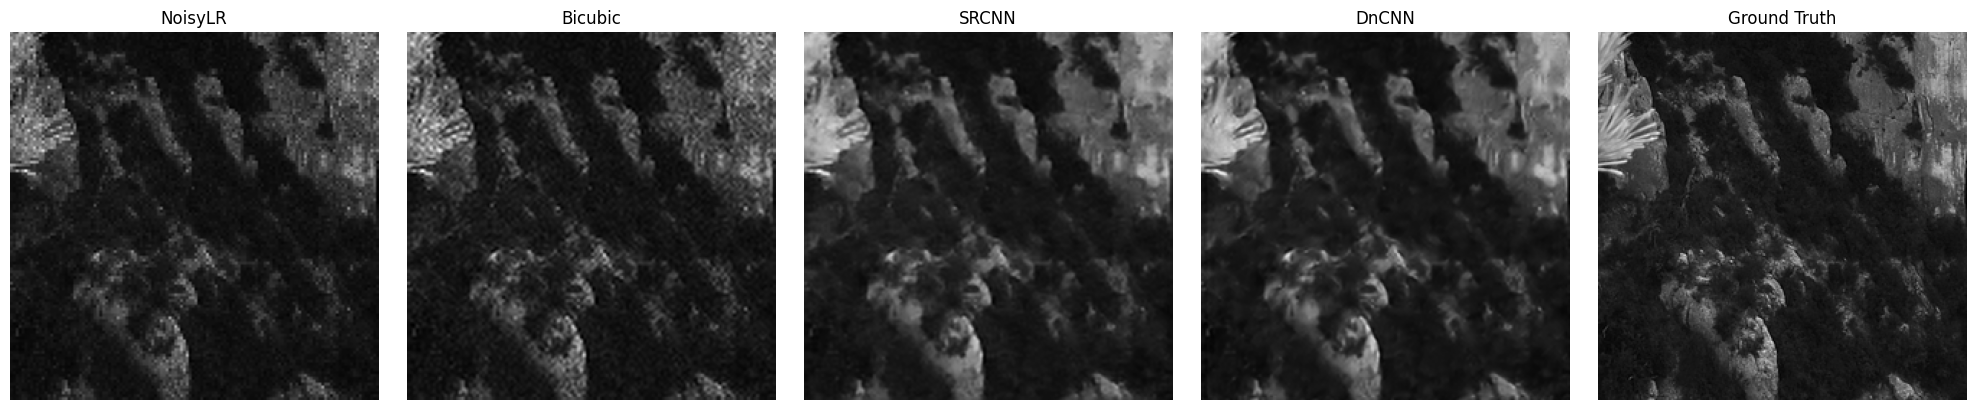

In [37]:
SRCNN_PATH = (
    "../results/srcnn/restored"
)


if os.path.exists(
    os.path.join(
        SRCNN_PATH,
        sample_file
    )
):


    srcnn = np.load(
        os.path.join(
            SRCNN_PATH,
            sample_file
        )
    )


    plt.figure(
        figsize=(20, 4)
    )


    plt.subplot(
        1,
        5,
        1
    )

    plt.imshow(
        noisy,
        cmap="gray"
    )

    plt.title(
        "NoisyLR"
    )

    plt.axis("off")


    plt.subplot(
        1,
        5,
        2
    )

    plt.imshow(
        bicubic,
        cmap="gray"
    )

    plt.title(
        "Bicubic"
    )

    plt.axis("off")


    plt.subplot(
        1,
        5,
        3
    )

    plt.imshow(
        srcnn,
        cmap="gray"
    )

    plt.title(
        "SRCNN"
    )

    plt.axis("off")


    plt.subplot(
        1,
        5,
        4
    )

    plt.imshow(
        dncnn,
        cmap="gray"
    )

    plt.title(
        "DnCNN"
    )

    plt.axis("off")


    plt.subplot(
        1,
        5,
        5
    )

    plt.imshow(
        gt,
        cmap="gray"
    )

    plt.title(
        "Ground Truth"
    )

    plt.axis("off")


    plt.tight_layout()


    plt.savefig(
        "../results/dncnn/all_baselines_visual.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


else:

    print(
        "SRCNN output for this test image not found."
    )

In [38]:
import shutil


sample_files = (
    test_files[:5]
)


for filename in sample_files:


    png_name = (
        filename.replace(
            ".npy",
            ".png"
        )
    )


    src = os.path.join(
        IMAGE_PATH,
        png_name
    )


    dst = os.path.join(
        EXAMPLE_PATH,
        png_name
    )


    if os.path.exists(
        src
    ):

        shutil.copy(
            src,
            dst
        )


print(
    "Example DnCNN images copied"
)

Example DnCNN images copied


In [39]:
bicubic_avg_psnr = np.mean(
    bicubic_psnr
)

bicubic_avg_ssim = np.mean(
    bicubic_ssim
)

bicubic_avg_mse = np.mean(
    bicubic_mse
)


print(
    "===== DnCNN Improvement ====="
)


print(
    f"PSNR gain over Bicubic: "
    f"{avg_psnr - bicubic_avg_psnr:.4f} dB"
)


print(
    f"PSNR gain over SRCNN: "
    f"{avg_psnr - srcnn_psnr:.4f} dB"
)


print(
    f"SSIM gain over Bicubic: "
    f"{avg_ssim - bicubic_avg_ssim:.4f}"
)


print(
    f"SSIM gain over SRCNN: "
    f"{avg_ssim - srcnn_ssim:.4f}"
)


mse_reduction_bicubic = (
    (
        bicubic_avg_mse
        -
        avg_mse
    )
    /
    bicubic_avg_mse
) * 100


mse_reduction_srcnn = (
    (
        srcnn_mse
        -
        avg_mse
    )
    /
    srcnn_mse
) * 100


print(
    f"MSE reduction over Bicubic: "
    f"{mse_reduction_bicubic:.2f}%"
)


print(
    f"MSE reduction over SRCNN: "
    f"{mse_reduction_srcnn:.2f}%"
)

===== DnCNN Improvement =====
PSNR gain over Bicubic: 5.4146 dB
PSNR gain over SRCNN: 0.3636 dB
SSIM gain over Bicubic: 0.2133
SSIM gain over SRCNN: -0.0001
MSE reduction over Bicubic: 64.91%
MSE reduction over SRCNN: 5.84%


In [40]:
print(
    "========== DnCNN OUTPUT CHECK =========="
)


print(
    "Best model:",
    os.path.exists(
        "../models/dncnn/dncnn_best.pth"
    )
)


print(
    "Final model:",
    os.path.exists(
        "../models/dncnn/dncnn_final.pth"
    )
)


print(
    "Training history:",
    os.path.exists(
        "../results/dncnn/training_history.csv"
    )
)


print(
    "Metrics:",
    os.path.exists(
        "../results/dncnn/metrics.txt"
    )
)


print(
    "Baseline comparison:",
    os.path.exists(
        "../results/dncnn/baseline_comparison.csv"
    )
)


print(
    "Visual comparison:",
    os.path.exists(
        "../results/dncnn/comparison.png"
    )
)


print(
    "Restored NPY files:",
    len([
        f for f in os.listdir(
            RESTORED_PATH
        )
        if f.endswith(
            ".npy"
        )
    ])
)


print(
    "PNG files:",
    len([
        f for f in os.listdir(
            IMAGE_PATH
        )
        if f.endswith(
            ".png"
        )
    ])
)

========== DnCNN OUTPUT CHECK ==========
Best model: True
Final model: True
Training history: True
Metrics: True
Baseline comparison: True
Visual comparison: True
Restored NPY files: 320
PNG files: 320
